# Task 2 – Step 2: Information Extraction Pipeline

## Design Axis: End-to-End Models vs. Decomposed Pipeline

This notebook implements and compares two approaches to extracting PIO fields from clinical trial abstracts in the EBM-NLP dataset. The three fields are Participants (P), Interventions (I) and Outcomes (O).

Note: The EBM-NLP dataset (Nye et al., 2018) uses crowd-sourced annotations. Comparators are not labelled separately — control conditions are grouped under Interventions by design, so we only extract P, I and O.

We compare three approaches. The first approach is a CRF baseline using hand-crafted medical features. The second is a single BioBERT model trained to predict all three entity types at once. The third is a decomposed pipeline that first filters sentences by relevance, then runs a separate BioBERT extractor for each field.

End-to-end hypothesis: A single BioBERT trained on all fields jointly should learn shared context and do better than the CRF with a simpler setup.

Decomposed hypothesis: Filtering out irrelevant sentences before extraction should give higher precision, though recall might drop if the filter removes sentences it shouldn't.

## 1. Imports

In [1]:
# Uncomment to install / upgrade packages if needed:
# !pip install transformers accelerate datasets seqeval python-crfsuite scikit-learn torch -q

import os, re, tarfile, unicodedata, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("ready")
print(f"PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}")

ready
PyTorch 2.6.0+cpu, CUDA: False


## 2. Data Loading

In [ ]:
archive = "./ebm_nlp_2_00.tar.gz"
if tarfile.is_tarfile(archive):
    with tarfile.open(archive) as f:
        f.extractall(path=".")
    print("Archive extracted.")
else:
    print("Already extracted or path wrong.")

In [2]:
DATA_DIR = Path("./ebm_nlp_2_00")

# Entity types and their short BIO tag labels
FIELDS = ["participants", "interventions", "outcomes"]
TAG_MAP = {"participants": "P", "interventions": "I", "outcomes": "O"}

def get_doc_ids(split, field):
    folder = "test/gold" if split == "test" else split
    ann_dir = DATA_DIR / "annotations/aggregated/hierarchical_labels" / field / folder
    return sorted(p.stem.split(".")[0] for p in ann_dir.glob("*.AGGREGATED.ann"))

def load_tokens(doc_id):
    with open(DATA_DIR / "documents" / f"{doc_id}.tokens") as f:
        return [line.strip() for line in f]

def load_raw_labels(doc_id, field, split):
    folder = "test/gold" if split == "test" else split
    path = DATA_DIR / "annotations/aggregated/hierarchical_labels" / field / folder / f"{doc_id}.AGGREGATED.ann"
    if not path.exists():
        return None
    with open(path) as f:
        return [line.strip() for line in f]

def to_bio(raw_tags):
    """Convert EBM-NLP hierarchical labels (0-4) to BIO tags."""
    bio, prev = [], 0
    for t in raw_tags:
        t = int(t)
        bio.append("O" if t == 0 else ("B" if prev == 0 else "I"))
        prev = t
    return bio

print("Data helpers defined.")

Data helpers defined.


In [3]:
# Load per-field BIO labels for all documents
all_data = {}

for field in FIELDS:
    all_data[field] = {}
    for split in ["train", "test"]:
        docs = []
        for doc_id in get_doc_ids(split, field):
            tokens    = load_tokens(doc_id)
            raw       = load_raw_labels(doc_id, field, split)
            if raw is None:
                continue
            bio = to_bio(raw)
            assert len(tokens) == len(bio), f"Length mismatch: {doc_id}"
            docs.append({"doc_id": doc_id, "tokens": tokens, "labels": bio})
        all_data[field][split] = docs
        print(f"{field} | {split} | {len(docs)} docs")

participants | train | 4609 docs
participants | test | 189 docs
interventions | train | 4746 docs
interventions | test | 187 docs
outcomes | train | 4681 docs
outcomes | test | 190 docs


### 2.1 Build a unified multi-label dataset

For the end-to-end model we merge all three field annotations into one tag set: B-P, I-P, B-I, I-I, B-O, I-O and O.

In [4]:
def merge_labels(all_data, split):
    """Combine P/I/O annotations into a single multi-label BIO sequence per document."""
    by_id = {field: {r["doc_id"]: r for r in all_data[field][split]} for field in FIELDS}
    common = set(by_id["participants"]) & set(by_id["interventions"]) & set(by_id["outcomes"])
    print(f"  {split}: {len(common)} docs with all three fields")

    merged_docs = []
    for doc_id in sorted(common):
        tokens = by_id["participants"][doc_id]["tokens"]
        tags = ["O"] * len(tokens)
        for field, short in TAG_MAP.items():
            for i, tag in enumerate(by_id[field][doc_id]["labels"]):
                if tag == "B":
                    tags[i] = f"B-{short}"
                elif tag == "I" and tags[i] == "O":
                    tags[i] = f"I-{short}"
        merged_docs.append({"doc_id": doc_id, "tokens": tokens, "labels": tags})
    return merged_docs

train_docs = merge_labels(all_data, "train")
test_docs  = merge_labels(all_data, "test")
print(f"train {len(train_docs)} docs, test {len(test_docs)} docs")

  train: 4457 docs with all three fields
  test: 184 docs with all three fields
train 4457 docs, test 184 docs


In [5]:
# Tag distribution
counts = defaultdict(int)
for doc in train_docs:
    for tag in doc["labels"]:
        counts[tag] += 1

total = sum(counts.values())
print("Tag distribution (train):")
for tag in sorted(counts):
    print(f"  {tag}: {counts[tag]} ({100*counts[tag]/total:.1f}%)")

Tag distribution (train):
  B-I: 30153 (2.5%)
  B-O: 31824 (2.6%)
  B-P: 14976 (1.2%)
  I-I: 53689 (4.4%)
  I-O: 79987 (6.6%)
  I-P: 34466 (2.8%)
  O: 973681 (79.9%)


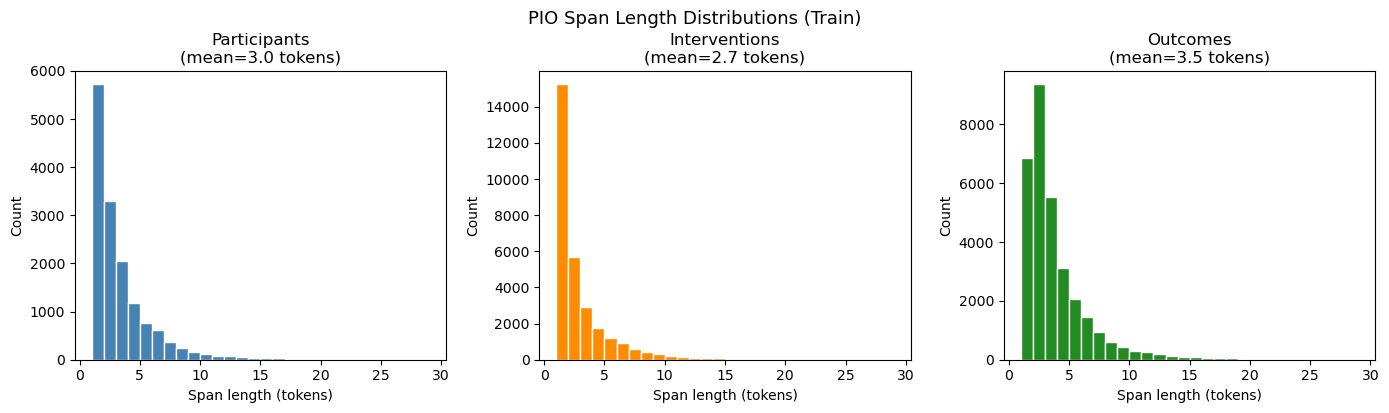

In [6]:
def span_lengths(docs, short):
    lengths, in_span, n = [], False, 0
    for doc in docs:
        for tag in doc["labels"]:
            if tag == f"B-{short}":
                in_span, n = True, 1
            elif tag == f"I-{short}" and in_span:
                n += 1
            else:
                if in_span: lengths.append(n)
                in_span = False
    return lengths

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colours = ["steelblue", "darkorange", "forestgreen"]
for ax, (field, short), col in zip(axes, TAG_MAP.items(), colours):
    lens = span_lengths(train_docs, short)
    ax.hist(lens, bins=range(1, 30), color=col, edgecolor="white")
    ax.set_title(f"{field.capitalize()}\n(mean={np.mean(lens):.1f} tokens)")
    ax.set_xlabel("Span length (tokens)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.suptitle("PIO Span Length Distributions (Train)", y=1.02, fontsize=13)
plt.savefig("span_lengths.png", bbox_inches="tight", dpi=120)
plt.show()

---
## 3. Evaluation

We use span-level precision, recall and F1 throughout, following the same approach as Lab 5. A prediction only counts as correct if the start index, end index and entity type all match the gold annotation exactly.

In [7]:
def get_spans(tag_seqs):
    """Extract entity spans from a list of BIO-tagged sequences."""
    spans = defaultdict(list)
    for sid, seq in enumerate(tag_seqs):
        start, cur_type = -1, None
        for i, tag in enumerate(seq):
            if tag.startswith("B-"):
                if start >= 0:
                    spans[cur_type].append((start, i, sid))
                start, cur_type = i, tag[2:]
            elif tag.startswith("I-") and start >= 0:
                pass
            else:
                if start >= 0:
                    spans[cur_type].append((start, i, sid))
                start, cur_type = -1, None
        if start >= 0:
            spans[cur_type].append((start, len(seq), sid))
    return dict(spans)


def eval_spans(gold_seqs, pred_seqs, fields=None):
    """Compute span-level P/R/F1 per field and macro average."""
    gold_spans = get_spans(gold_seqs)
    pred_spans = get_spans(pred_seqs)
    if fields is None:
        fields = sorted(set(gold_spans) | set(pred_spans))

    scores = {}
    f1s = []
    for f in fields:
        g = set(gold_spans.get(f, []))
        p = set(pred_spans.get(f, []))
        tp = len(g & p)
        fp = len(p - g)
        fn = len(g - p)
        prec = tp / (tp + fp) if tp + fp > 0 else 0.0
        rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1   = 2*prec*rec / (prec+rec) if prec+rec > 0 else 0.0
        scores[f] = {"precision": prec, "recall": rec, "f1": f1, "support": len(g)}
        f1s.append(f1)

    scores["macro"] = {
        "precision": np.mean([scores[f]["precision"] for f in fields]),
        "recall":    np.mean([scores[f]["recall"]    for f in fields]),
        "f1":        np.mean(f1s),
    }
    return scores


def show_results(scores, title="Results"):
    print(f"\n{title}")
    print("field          prec     rec       f1      n")
    for f, s in scores.items():
        supp = s.get("support", "")
        print(f"{f:<14} {s['precision']:9.3f} {s['recall']:9.3f} {s['f1']:9.3f}   {supp}")

print("Evaluation utilities defined.")

Evaluation utilities defined.


---
## 4. CRF Baseline

A CRF with hand-crafted medical features gives a classical baseline. We train one CRF per field and merge the predictions at the end.

Hypothesis: The CRF should get reasonable recall since medical keywords are a good signal, but lower precision than BERT because it has no way to use wider sentence context.

In [8]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

class PioCRF(nltk.tag.CRFTagger):
    """CRF tagger with medical domain features, one per PIO field."""
    MED_WORDS = {
        "participants":  {"patients","participants","subjects","adults","children",
                          "women","men","elderly","infants","volunteers","aged","cohort"},
        "interventions": {"treatment","therapy","drug","dose","mg","intervention",
                          "medication","surgery","placebo","randomized","assigned"},
        "outcomes":      {"outcome","mortality","survival","reduction","improvement",
                          "score","rate","efficacy","adverse","response","remission"},
    }

    def __init__(self, field="participants", **kw):
        super().__init__(**kw)
        self.field = field
        self.keywords = self.MED_WORDS.get(field, set())

    def _get_features(self, tokens, idx):
        tok   = tokens[idx]
        lower = tok.lower()
        feats = []

        if not tok:
            return feats

        # Shape features
        if tok[0].isupper():      feats.append("CAP")
        if tok.isupper():         feats.append("ALL_CAPS")
        if re.search(r"\d", tok): feats.append("HAS_NUM")
        if re.search(r"-", tok):  feats.append("HAS_HYPHEN")

        # Prefix / suffix
        for n in (2, 3, 4):
            if len(tok) > n: feats.append(f"SUF{n}_{tok[-n:].lower()}")
        for n in (2, 3):
            if len(tok) >= n: feats.append(f"PRE{n}_{tok[:n].lower()}")

        feats.append(f"W_{lower}")
        if lower in self.keywords:
            feats.append("MED_KW")

        # Context
        if idx > 0:
            feats.append(f"PREV_{tokens[idx-1].lower()}")
        else:
            feats.append("BOS")
        if idx < len(tokens) - 1:
            feats.append(f"NEXT_{tokens[idx+1].lower()}")
        else:
            feats.append("EOS")

        return feats


def train_crf(field, train_docs, all_data):
    """Train a CRF tagger for one PIO field."""
    id2bio = {r["doc_id"]: r["labels"] for r in all_data[field]["train"]}
    train_set = []
    for doc in train_docs:
        if doc["doc_id"] not in id2bio:
            continue
        train_set.append(list(zip(doc["tokens"], id2bio[doc["doc_id"]])))
    tagger = PioCRF(field=field)
    tagger.train(train_set, f"crf_{field}.model")
    return tagger


print("training CRFs...")
crfs = {}
for field in FIELDS:
    print(f"  {field}...")
    crfs[field] = train_crf(field, train_docs, all_data)
print("Done.")

training CRFs...
  participants...
  interventions...
  outcomes...
Done.


In [9]:
def crf_predict(crfs, docs):
    """Run all three CRFs and merge into multi-label BIO sequences."""
    priority = {"P": 0, "I": 1, "O": 2}
    preds = []
    for doc in docs:
        tokens = doc["tokens"]
        per_field = {
            short: [t for _, t in crfs[field].tag(tokens)]
            for field, short in TAG_MAP.items()
        }
        merged = []
        for i in range(len(tokens)):
            best, best_pri = "O", 999
            for short in ["P", "I", "O"]:
                t = per_field[short][i]
                if t != "O" and priority[short] < best_pri:
                    best, best_pri = f"{t}-{short}", priority[short]
            merged.append(best)
        preds.append(merged)
    return preds


gold = [doc["labels"] for doc in test_docs]
crf_preds = crf_predict(crfs, test_docs)
crf_scores = eval_spans(gold, crf_preds, fields=["P", "I", "O"])
show_results(crf_scores, "CRF baseline")


CRF baseline
field          prec     rec       f1      n
P                  0.300     0.128     0.180   664
I                  0.572     0.284     0.379   1473
O                  0.369     0.175     0.238   1347
macro              0.414     0.196     0.265   


---
## 5. End-to-End BioBERT

A single BioBERT model predicts tags for all three fields at once.

Hypothesis: BioBERT should outperform the CRF because self-attention can use the whole sentence, and training on all three fields at once lets the model pick up shared patterns across entity types.

In [10]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
from torch.utils.data import Dataset

TAGS = ["O", "B-P", "I-P", "B-I", "I-I", "B-O", "I-O"]
tag2id = {t: i for i, t in enumerate(TAGS)}
id2tag = {i: t for t, i in tag2id.items()}
MODEL = "dmis-lab/biobert-base-cased-v1.2"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
print("Tokenizer loaded.")

Tokenizer loaded.


In [11]:
class NERDataset(Dataset):
    """PyTorch Dataset for token classification with sub-word label alignment."""
    def __init__(self, docs, tokenizer, tag2id, max_len=512):
        self.data = self._encode(docs, tokenizer, tag2id, max_len)

    def _encode(self, docs, tokenizer, tag2id, max_len):
        encoded = []
        for doc in docs:
            out = tokenizer(
                doc["tokens"],
                is_split_into_words=True,
                max_length=max_len,
                truncation=True,
                padding="max_length",
            )
            word_ids = out.word_ids()
            label_ids = []
            prev = None
            for wid in word_ids:
                if wid is None:
                    label_ids.append(-100)
                elif wid != prev:
                    label_ids.append(tag2id[doc["labels"][wid]])
                else:
                    label_ids.append(-100)
                prev = wid
            out["labels"] = label_ids
            encoded.append(out)
        return encoded

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return {k: torch.tensor(v) for k, v in self.data[i].items()}


# 90/10 train/val split
n_val = max(1, int(0.1 * len(train_docs)))
train_ds = NERDataset(train_docs[n_val:], tokenizer, tag2id)
val_ds   = NERDataset(train_docs[:n_val], tokenizer, tag2id)
test_ds  = NERDataset(test_docs,          tokenizer, tag2id)
print(f"train {len(train_ds)}, val {len(val_ds)}, test {len(test_ds)}")

train 4012, val 445, test 184


In [12]:
import inspect
from packaging import version as pver

def make_args(out_dir, epochs, train_bs=8, eval_bs=16, lr=5e-5, log_steps=50):
    """Build TrainingArguments compatible with both old and new transformers."""
    params = inspect.signature(TrainingArguments.__init__).parameters
    eval_key = "eval_strategy" if "eval_strategy" in params else "evaluation_strategy"

    return TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        learning_rate=lr,
        **{eval_key: "epoch"},
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=log_steps,
        seed=SEED,
        report_to="none",
    )

print("make_args helper defined.")

make_args helper defined.


In [13]:
from seqeval.metrics import f1_score as seq_f1

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)
    true = [[id2tag[l] for l in row if l != -100] for row in labels]
    pred = [[id2tag[p] for p, l in zip(pr, lr) if l != -100]
            for pr, lr in zip(preds, labels)]
    return {"f1": seq_f1(true, pred, average="macro")}


# Phase 1: train the classification head only
e2e_model = AutoModelForTokenClassification.from_pretrained(
    MODEL, num_labels=len(TAGS), id2label=id2tag, label2id=tag2id
)
for p in e2e_model.bert.parameters():
    p.requires_grad = False
print(f"trainable params (head only): {sum(p.numel() for p in e2e_model.parameters() if p.requires_grad):,}")

trainer = Trainer(
    model=e2e_model,
    args=make_args("checkpoints_e2e", epochs=4, train_bs=8),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)
print("training head...")
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

trainable params (head only): 5,383
training head...
{'loss': '1.797', 'grad_norm': '6.805', 'learning_rate': '4.878e-05', 'epoch': '0.0996'}
{'loss': '1.489', 'grad_norm': '5', 'learning_rate': '4.753e-05', 'epoch': '0.1992'}
{'loss': '1.233', 'grad_norm': '3.94', 'learning_rate': '4.629e-05', 'epoch': '0.2988'}
{'loss': '1.054', 'grad_norm': '2.564', 'learning_rate': '4.504e-05', 'epoch': '0.3984'}
{'loss': '0.9306', 'grad_norm': '1.858', 'learning_rate': '4.38e-05', 'epoch': '0.498'}
{'loss': '0.8658', 'grad_norm': '1.27', 'learning_rate': '4.255e-05', 'epoch': '0.5976'}
{'loss': '0.815', 'grad_norm': '0.7395', 'learning_rate': '4.131e-05', 'epoch': '0.6972'}
{'loss': '0.765', 'grad_norm': '0.588', 'learning_rate': '4.006e-05', 'epoch': '0.7968'}
{'loss': '0.7492', 'grad_norm': '0.564', 'learning_rate': '3.882e-05', 'epoch': '0.8964'}
{'loss': '0.7168', 'grad_norm': '0.4256', 'learning_rate': '3.757e-05', 'epoch': '0.996'}
{'eval_loss': '0.7019', 'eval_f1': '0', 'eval_runtime': '51.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.7023', 'grad_norm': '0.7647', 'learning_rate': '3.633e-05', 'epoch': '1.096'}
{'loss': '0.6933', 'grad_norm': '0.5337', 'learning_rate': '3.508e-05', 'epoch': '1.195'}
{'loss': '0.6853', 'grad_norm': '0.8088', 'learning_rate': '3.384e-05', 'epoch': '1.295'}
{'loss': '0.6766', 'grad_norm': '0.4632', 'learning_rate': '3.259e-05', 'epoch': '1.394'}
{'loss': '0.6709', 'grad_norm': '0.415', 'learning_rate': '3.135e-05', 'epoch': '1.494'}
{'loss': '0.6694', 'grad_norm': '0.4474', 'learning_rate': '3.01e-05', 'epoch': '1.594'}
{'loss': '0.6504', 'grad_norm': '0.7871', 'learning_rate': '2.886e-05', 'epoch': '1.693'}
{'loss': '0.6412', 'grad_norm': '0.3183', 'learning_rate': '2.761e-05', 'epoch': '1.793'}
{'loss': '0.6362', 'grad_norm': '0.5135', 'learning_rate': '2.637e-05', 'epoch': '1.892'}
{'loss': '0.6396', 'grad_norm': '0.4987', 'learning_rate': '2.512e-05', 'epoch': '1.992'}
{'eval_loss': '0.6122', 'eval_f1': '0.04894', 'eval_runtime': '53.97', 'eval_samples_per_second': '8.2

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6116', 'grad_norm': '0.4309', 'learning_rate': '1.143e-05', 'epoch': '3.088'}
{'loss': '0.6021', 'grad_norm': '0.3978', 'learning_rate': '1.018e-05', 'epoch': '3.187'}
{'loss': '0.6114', 'grad_norm': '0.3716', 'learning_rate': '8.939e-06', 'epoch': '3.287'}
{'loss': '0.5903', 'grad_norm': '0.4892', 'learning_rate': '7.694e-06', 'epoch': '3.386'}
{'loss': '0.5966', 'grad_norm': '0.3427', 'learning_rate': '6.449e-06', 'epoch': '3.486'}
{'loss': '0.5817', 'grad_norm': '0.3349', 'learning_rate': '5.204e-06', 'epoch': '3.586'}
{'loss': '0.597', 'grad_norm': '0.7545', 'learning_rate': '3.959e-06', 'epoch': '3.685'}
{'loss': '0.5844', 'grad_norm': '0.5906', 'learning_rate': '2.714e-06', 'epoch': '3.785'}
{'loss': '0.5935', 'grad_norm': '0.7007', 'learning_rate': '1.469e-06', 'epoch': '3.884'}
{'loss': '0.5879', 'grad_norm': '0.5217', 'learning_rate': '2.241e-07', 'epoch': '3.984'}
{'eval_loss': '0.5737', 'eval_f1': '0.0948', 'eval_runtime': '54.91', 'eval_samples_per_second': '8.1

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '4009', 'train_samples_per_second': '4.003', 'train_steps_per_second': '0.501', 'train_loss': '0.7285', 'epoch': '4'}


TrainOutput(global_step=2008, training_loss=0.728476429128077, metrics={'train_runtime': 4009.4761, 'train_samples_per_second': 4.003, 'train_steps_per_second': 0.501, 'train_loss': 0.728476429128077, 'epoch': 4.0})

In [14]:
# Phase 2: unfreeze all layers and fine-tune
for p in e2e_model.bert.parameters():
    p.requires_grad = True
print(f"trainable params (all layers): {sum(p.numel() for p in e2e_model.parameters() if p.requires_grad):,}")

trainer_full = Trainer(
    model=e2e_model,
    args=make_args("checkpoints_e2e_full", epochs=2, train_bs=4, lr=2e-5),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)
print("fine-tuning...")
trainer_full.train()

trainable params (all layers): 107,725,063
fine-tuning...
{'loss': '0.5115', 'grad_norm': '3.857', 'learning_rate': '1.951e-05', 'epoch': '0.04985'}
{'loss': '0.459', 'grad_norm': '1.501', 'learning_rate': '1.901e-05', 'epoch': '0.0997'}
{'loss': '0.4224', 'grad_norm': '2.708', 'learning_rate': '1.851e-05', 'epoch': '0.1496'}
{'loss': '0.4446', 'grad_norm': '2.032', 'learning_rate': '1.802e-05', 'epoch': '0.1994'}
{'loss': '0.4179', 'grad_norm': '3.23', 'learning_rate': '1.752e-05', 'epoch': '0.2493'}
{'loss': '0.4083', 'grad_norm': '1.218', 'learning_rate': '1.702e-05', 'epoch': '0.2991'}
{'loss': '0.3995', 'grad_norm': '1.091', 'learning_rate': '1.652e-05', 'epoch': '0.349'}
{'loss': '0.3878', 'grad_norm': '1.699', 'learning_rate': '1.602e-05', 'epoch': '0.3988'}
{'loss': '0.4046', 'grad_norm': '1.533', 'learning_rate': '1.552e-05', 'epoch': '0.4487'}
{'loss': '0.389', 'grad_norm': '1.458', 'learning_rate': '1.502e-05', 'epoch': '0.4985'}
{'loss': '0.4108', 'grad_norm': '0.9708', 'le

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.344', 'grad_norm': '1.293', 'learning_rate': '9.541e-06', 'epoch': '1.047'}
{'loss': '0.3546', 'grad_norm': '4.274', 'learning_rate': '9.043e-06', 'epoch': '1.097'}
{'loss': '0.3555', 'grad_norm': '2.227', 'learning_rate': '8.544e-06', 'epoch': '1.147'}
{'loss': '0.3505', 'grad_norm': '1.15', 'learning_rate': '8.046e-06', 'epoch': '1.196'}
{'loss': '0.3576', 'grad_norm': '1.123', 'learning_rate': '7.547e-06', 'epoch': '1.246'}
{'loss': '0.3807', 'grad_norm': '2.273', 'learning_rate': '7.049e-06', 'epoch': '1.296'}
{'loss': '0.3431', 'grad_norm': '1.831', 'learning_rate': '6.55e-06', 'epoch': '1.346'}
{'loss': '0.3519', 'grad_norm': '1.043', 'learning_rate': '6.052e-06', 'epoch': '1.396'}
{'loss': '0.3647', 'grad_norm': '2.311', 'learning_rate': '5.553e-06', 'epoch': '1.446'}
{'loss': '0.3479', 'grad_norm': '1.814', 'learning_rate': '5.055e-06', 'epoch': '1.496'}
{'loss': '0.3704', 'grad_norm': '1.543', 'learning_rate': '4.556e-06', 'epoch': '1.545'}
{'loss': '0.3623', 'grad

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '5069', 'train_samples_per_second': '1.583', 'train_steps_per_second': '0.396', 'train_loss': '0.3812', 'epoch': '2'}


TrainOutput(global_step=2006, training_loss=0.3811747475136313, metrics={'train_runtime': 5069.1779, 'train_samples_per_second': 1.583, 'train_steps_per_second': 0.396, 'train_loss': 0.3811747475136313, 'epoch': 2.0})

In [15]:
def eval_model(trainer, dataset):
    """Run inference and return span-level F1 scores."""
    out = trainer.predict(dataset)
    pred_ids = np.argmax(out.predictions, axis=2)
    label_ids = out.label_ids

    gold_seqs = [[id2tag[l] for l in row if l != -100] for row in label_ids]
    pred_seqs = [[id2tag[p] for p, l in zip(pr, lr) if l != -100]
                 for pr, lr in zip(pred_ids, label_ids)]
    return eval_spans(gold_seqs, pred_seqs, fields=["P", "I", "O"])


e2e_scores = eval_model(trainer_full, test_ds)
show_results(e2e_scores, "End-to-end BioBERT")


End-to-end BioBERT
field          prec     rec       f1      n
P                  0.253     0.262     0.258   652
I                  0.608     0.583     0.595   1423
O                  0.456     0.414     0.434   1300
macro              0.439     0.420     0.429   


---
## 6. Decomposed Pipeline

This approach splits extraction into two steps. First, a TF-IDF + Logistic Regression classifier (following Lab 3) decides whether each sentence contains a given entity type. Second, a BioBERT token classifier runs only on sentences marked as relevant, one model per field.

The idea is that many sentences in a clinical abstract are background and contain no PIO entities. Filtering these out before extraction should reduce false positives. Using a lightweight LR classifier for this step keeps runtime reasonable compared to running BERT on every sentence.

Hypothesis: Precision should be higher than the end-to-end approach because we skip irrelevant sentences. Recall might drop if the filter throws away sentences it shouldn't.

### 6.1 Split documents into sentences

In [16]:
import nltk
nltk.download('punkt_tab', quiet=True)

def split_sentences(doc):
    """Split a token-level doc into sentences on punctuation."""
    sents = []
    toks, labs = [], []
    for tok, lab in zip(doc["tokens"], doc["labels"]):
        toks.append(tok)
        labs.append(lab)
        if tok in (".", "!", "?") and len(toks) > 3:
            sents.append((toks[:], labs[:]))
            toks, labs = [], []
    if toks:
        sents.append((toks, labs))
    return sents


def make_sent_data(docs, short):
    """Build sentence-level samples with binary relevance label for one field."""
    samples = []
    for doc in docs:
        for toks, labs in split_sentences(doc):
            has_ent = any(lab.endswith(f"-{short}") for lab in labs)
            samples.append({
                "text": " ".join(toks),
                "tokens": toks,
                "labels": labs,
                "relevant": int(has_ent),
            })
    return samples


sent_data = {}
for field, short in TAG_MAP.items():
    sent_data[field] = {
        "train": make_sent_data(train_docs, short),
        "test": make_sent_data(test_docs, short),
    }
    n_pos = sum(s["relevant"] for s in sent_data[field]["train"])
    print(f"{field} | train sents: {len(sent_data[field]['train'])} | relevant: {n_pos}")

participants | train sents: 47897 | relevant: 10504
interventions | train sents: 47897 | relevant: 19683
outcomes | train sents: 47897 | relevant: 20943


### 6.2 Step 1： Sentence Relevance Classifier (TF-IDF + Logistic Regression)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

def train_relevance(samples):
    """Train TF-IDF + LR relevance classifier (fast, no GPU needed)."""
    texts = [s["text"]     for s in samples]
    labels = [s["relevant"] for s in samples]
    clf = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                                  max_features=50_000, sublinear_tf=True)),
        ("lr",    LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)),
    ])
    clf.fit(texts, labels)
    return clf


print("training relevance classifiers...")
rel_clfs = {}
for field in FIELDS:
    rel_clfs[field] = train_relevance(sent_data[field]["train"])
    test_texts = [s["text"]     for s in sent_data[field]["test"]]
    test_labs  = [s["relevant"] for s in sent_data[field]["test"]]
    preds = rel_clfs[field].predict(test_texts)
    f1 = f1_score(test_labs, preds, pos_label=1)
    print(f"  {field} | relevance F1: {f1:.3f}")
print("Done.")

training relevance classifiers...
  participants | relevance F1: 0.770
  interventions | relevance F1: 0.734
  outcomes | relevance F1: 0.755
Done.


### 6.3 Step 2： Per-Field Span Extractor (BioBERT)

In [19]:
from torch.utils.data import Dataset as TorchDataset

class FieldDataset(TorchDataset):
    """Token classification dataset for a single PIO field."""
    def __init__(self, samples, tokenizer, field_short, max_len=256):
        tags = ["O", f"B-{field_short}", f"I-{field_short}"]
        self.t2id = {t: i for i, t in enumerate(tags)}
        self.id2t = {i: t for t, i in self.t2id.items()}
        self.data = self._encode(samples, tokenizer, field_short, max_len)

    def _encode(self, samples, tokenizer, short, max_len):
        encoded = []
        for s in samples:
            # keep only tags for this field
            field_labs = [lab if lab.endswith(f"-{short}") else "O" for lab in s["labels"]]
            out = tokenizer(
                s["tokens"], is_split_into_words=True,
                max_length=max_len, truncation=True, padding="max_length",
            )
            word_ids = out.word_ids()
            label_ids = []
            prev = None
            for wid in word_ids:
                if wid is None:
                    label_ids.append(-100)
                elif wid != prev:
                    label_ids.append(self.t2id[field_labs[wid]])
                else:
                    label_ids.append(-100)
                prev = wid
            out["labels"] = label_ids
            encoded.append(out)
        return encoded

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return {k: torch.tensor(v) for k, v in self.data[i].items()}

def compute_metrics_3class(eval_pred, id2t):
    """Compute F1 for 3-class token classification (O, B-X, I-X)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)
    true = [[id2t[l] for l in row if l != -100] for row in labels]
    pred = [[id2t[p] for p, l in zip(pr, lr) if l != -100]
            for pr, lr in zip(preds, labels)]
    return {"f1": seq_f1(true, pred, average="macro")}

def train_extractor(samples, field, short):
    """Train a BioBERT span extractor for one field on balanced samples."""
    pos = [s for s in samples if s["relevant"] == 1]
    neg = [s for s in samples if s["relevant"] == 0][:len(pos)]
    balanced = pos + neg

    n_val = max(1, int(0.1 * len(balanced)))
    ds_tr = FieldDataset(balanced[n_val:], tokenizer, short)
    ds_val = FieldDataset(balanced[:n_val], tokenizer, short)

    model = AutoModelForTokenClassification.from_pretrained(
        MODEL, num_labels=3,
        id2label=ds_tr.id2t, label2id=ds_tr.t2id,
    )

    training_args = make_args(f"checkpoints_{field}", epochs=4, train_bs=8, log_steps=100)
    training_args.metric_for_best_model = "eval_f1"

    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_tr,
        eval_dataset=ds_val,
        data_collator=DataCollatorForTokenClassification(tokenizer),
        compute_metrics=lambda eval_pred: compute_metrics_3class(eval_pred, ds_tr.id2t),
    )
    trainer.train()
    return model, ds_tr.t2id, ds_tr.id2t


print("training span extractors...")
extractors = {}
for field, short in TAG_MAP.items():
    print(f"  {field} ({short})...")
    extractors[field] = train_extractor(sent_data[field]["train"], field, short)
print("done")

training span extractors...
  participants (P)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.2536', 'grad_norm': '1.709', 'learning_rate': '4.948e-05', 'epoch': '0.0423'}
{'loss': '0.1983', 'grad_norm': '1.102', 'learning_rate': '4.895e-05', 'epoch': '0.0846'}
{'loss': '0.1863', 'grad_norm': '0.6601', 'learning_rate': '4.842e-05', 'epoch': '0.1269'}
{'loss': '0.1814', 'grad_norm': '1.12', 'learning_rate': '4.789e-05', 'epoch': '0.1692'}
{'loss': '0.1921', 'grad_norm': '1.086', 'learning_rate': '4.736e-05', 'epoch': '0.2115'}
{'loss': '0.1615', 'grad_norm': '2.007', 'learning_rate': '4.683e-05', 'epoch': '0.2538'}
{'loss': '0.1764', 'grad_norm': '1.113', 'learning_rate': '4.63e-05', 'epoch': '0.2961'}
{'loss': '0.1997', 'grad_norm': '0.8417', 'learning_rate': '4.578e-05', 'epoch': '0.3384'}
{'loss': '0.2274', 'grad_norm': '3.548', 'learning_rate': '4.525e-05', 'epoch': '0.3807'}
{'loss': '0.182', 'grad_norm': '0.7153', 'learning_rate': '4.472e-05', 'epoch': '0.423'}
{'loss': '0.1584', 'grad_norm': '1.729', 'learning_rate': '4.419e-05', 'epoch': '0.4653'}
{'loss': '0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1629', 'grad_norm': '0.8424', 'learning_rate': '3.731e-05', 'epoch': '1.015'}
{'loss': '0.1721', 'grad_norm': '1.219', 'learning_rate': '3.679e-05', 'epoch': '1.058'}
{'loss': '0.1309', 'grad_norm': '1.465', 'learning_rate': '3.626e-05', 'epoch': '1.1'}
{'loss': '0.1449', 'grad_norm': '1.1', 'learning_rate': '3.573e-05', 'epoch': '1.142'}
{'loss': '0.1447', 'grad_norm': '0.4425', 'learning_rate': '3.52e-05', 'epoch': '1.184'}
{'loss': '0.1525', 'grad_norm': '2.139', 'learning_rate': '3.467e-05', 'epoch': '1.227'}
{'loss': '0.1615', 'grad_norm': '2.839', 'learning_rate': '3.414e-05', 'epoch': '1.269'}
{'loss': '0.1378', 'grad_norm': '0.7162', 'learning_rate': '3.361e-05', 'epoch': '1.311'}
{'loss': '0.1401', 'grad_norm': '1.088', 'learning_rate': '3.308e-05', 'epoch': '1.354'}
{'loss': '0.1391', 'grad_norm': '0.2368', 'learning_rate': '3.256e-05', 'epoch': '1.396'}
{'loss': '0.1495', 'grad_norm': '0.5974', 'learning_rate': '3.203e-05', 'epoch': '1.438'}
{'loss': '0.1525', 'g

...

{'loss': '0.1235', 'grad_norm': '3.232', 'learning_rate': '2.481e-05', 'epoch': '2.016'}
{'loss': '0.1227', 'grad_norm': '0.6126', 'learning_rate': '2.454e-05', 'epoch': '2.037'}
{'loss': '0.1065', 'grad_norm': '3.25', 'learning_rate': '2.428e-05', 'epoch': '2.058'}
{'loss': '0.1193', 'grad_norm': '1.982', 'learning_rate': '2.401e-05', 'epoch': '2.079'}
{'loss': '0.1082', 'grad_norm': '1.371', 'learning_rate': '2.375e-05', 'epoch': '2.101'}
{'loss': '0.1064', 'grad_norm': '1.384', 'learning_rate': '2.348e-05', 'epoch': '2.122'}
{'loss': '0.1184', 'grad_norm': '1.06', 'learning_rate': '2.322e-05', 'epoch': '2.143'}
{'loss': '0.1133', 'grad_norm': '1.802', 'learning_rate': '2.295e-05', 'epoch': '2.164'}
{'loss': '0.1039', 'grad_norm': '6.607', 'learning_rate': '2.268e-05', 'epoch': '2.185'}
{'loss': '0.146', 'grad_norm': '0.8989', 'learning_rate': '2.242e-05', 'epoch': '2.207'}
{'loss': '0.1107', 'grad_norm': '2.295', 'learning_rate': '2.215e-05', 'epoch': '2.228'}
{'loss': '0.1107', 'gr

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1025', 'grad_norm': '0.9865', 'learning_rate': '1.234e-05', 'epoch': '3.013'}
{'loss': '0.08085', 'grad_norm': '0.9769', 'learning_rate': '1.208e-05', 'epoch': '3.034'}
{'loss': '0.07589', 'grad_norm': '1.77', 'learning_rate': '1.181e-05', 'epoch': '3.055'}
{'loss': '0.0729', 'grad_norm': '10.56', 'learning_rate': '1.155e-05', 'epoch': '3.077'}
{'loss': '0.07042', 'grad_norm': '1.664', 'learning_rate': '1.128e-05', 'epoch': '3.098'}
{'loss': '0.07642', 'grad_norm': '0.6491', 'learning_rate': '1.101e-05', 'epoch': '3.119'}
{'loss': '0.06794', 'grad_norm': '2.239', 'learning_rate': '1.075e-05', 'epoch': '3.14'}
{'loss': '0.08862', 'grad_norm': '3.366', 'learning_rate': '1.048e-05', 'epoch': '3.161'}
{'loss': '0.07682', 'grad_norm': '2.32', 'learning_rate': '1.022e-05', 'epoch': '3.183'}
{'loss': '0.08517', 'grad_norm': '0.9821', 'learning_rate': '9.954e-06', 'epoch': '3.204'}
{'loss': '0.08628', 'grad_norm': '1.147', 'learning_rate': '9.689e-06', 'epoch': '3.225'}
{'loss': '0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '4.593e+04', 'train_samples_per_second': '3.283', 'train_steps_per_second': '0.41', 'train_loss': '0.1328', 'epoch': '4'}
done


### 6.4 Inference： Decomposed Pipeline

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def is_relevant(clf, text):
    """Return True if the sentence is relevant for this field."""
    return bool(clf.predict([text])[0])


def predict_tags(model, tokens, id2t, max_len=256):
    """Predict BIO tags for a token sequence using a span extractor model."""
    model.eval()
    enc = tokenizer(
        tokens, is_split_into_words=True,
        max_length=max_len, truncation=True, padding="max_length", return_tensors="pt"
    ).to(device)
    model.to(device)
    with torch.no_grad():
        pred_ids = torch.argmax(model(**enc).logits, dim=2).squeeze().tolist()

    result, prev = [], None
    for pid, wid in zip(pred_ids, enc.word_ids()):
        if wid is None or wid == prev:
            continue
        result.append(id2t[pid])
        prev = wid

    # pad back to original length if truncated
    while len(result) < len(tokens): result.append("O")
    return result[:len(tokens)]


def run_pipeline(docs, rel_clfs, extractors):
    """Run the full decomposed pipeline and return merged BIO predictions."""
    all_preds = []
    for doc in docs:
        n = len(doc["tokens"])
        merged = ["O"] * n
        sents = split_sentences(doc)

        for field, short in TAG_MAP.items():
            clf = rel_clfs[field]
            model, _, id2t = extractors[field]
            cursor = 0
            for toks, _ in sents:
                text = " ".join(toks)
                if is_relevant(clf, text):
                    tags = predict_tags(model, toks, id2t)
                    for j, tag in enumerate(tags):
                        gi = cursor + j
                        if gi < n and tag != "O" and merged[gi] == "O":
                            merged[gi] = tag
                cursor += len(toks)

        all_preds.append(merged)
    return all_preds


print("running on test set...")
decomposed_preds = run_pipeline(test_docs, rel_clfs, extractors)
decomposed_scores = eval_spans(gold, decomposed_preds, fields=["P", "I", "O"])
show_results(decomposed_scores, "Decomposed pipeline")

running on test set...

Decomposed pipeline
field          prec     rec       f1      n
P                  0.225     0.252     0.237   664
I                  0.605     0.366     0.456   1473
O                  0.400     0.376     0.388   1347
macro              0.410     0.331     0.360   


---
## 7. Comparative Evaluation

In [21]:
all_scores = {
    "CRF":       crf_scores,
    "E2E":       e2e_scores,
    "Decomposed": decomposed_scores,
}

for name, s in all_scores.items():
    show_results(s, name)


CRF
field          prec     rec       f1      n
P                  0.300     0.128     0.180   664
I                  0.572     0.284     0.379   1473
O                  0.369     0.175     0.238   1347
macro              0.414     0.196     0.265   

E2E
field          prec     rec       f1      n
P                  0.253     0.262     0.258   652
I                  0.608     0.583     0.595   1423
O                  0.456     0.414     0.434   1300
macro              0.439     0.420     0.429   

Decomposed
field          prec     rec       f1      n
P                  0.225     0.252     0.237   664
I                  0.605     0.366     0.456   1473
O                  0.400     0.376     0.388   1347
macro              0.410     0.331     0.360   


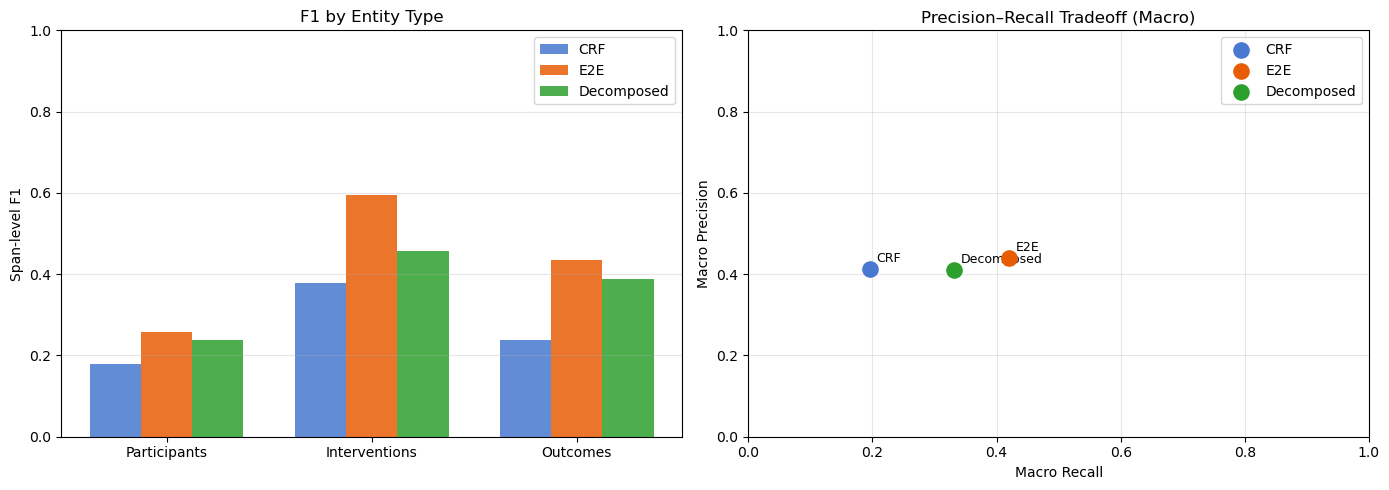

In [22]:
shorts = ["P", "I", "O"]
names  = ["Participants", "Interventions", "Outcomes"]
cols   = ["#4878CF", "#E85D04", "#2CA02C"]
x      = np.arange(len(shorts))
w      = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 by entity
for i, (apname, s) in enumerate(all_scores.items()):
    f1s = [s.get(sh, {"f1": 0})["f1"] for sh in shorts]
    ax1.bar(x + i*w, f1s, w, label=apname, color=cols[i], alpha=0.85)
ax1.set_xticks(x + w)
ax1.set_xticklabels(names)
ax1.set_ylabel("Span-level F1")
ax1.set_title("F1 by Entity Type")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Precision-Recall scatter
for (apname, s), col in zip(all_scores.items(), cols):
    m = s["macro"]
    ax2.scatter(m["recall"], m["precision"], s=120, color=col, label=apname, zorder=5)
    ax2.annotate(apname, (m["recall"], m["precision"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.set_xlabel("Macro Recall")
ax2.set_ylabel("Macro Precision")
ax2.set_title("Precision–Recall Tradeoff (Macro)")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("comparison.png", bbox_inches="tight", dpi=120)
plt.show()

In [23]:
rows = []
for apname, s in all_scores.items():
    for f in shorts + ["macro"]:
        r = s.get(f, s["macro"])
        rows.append({
            "Approach": apname, "Field": f,
            "Precision": round(r["precision"], 3),
            "Recall":    round(r["recall"],    3),
            "F1":        round(r["f1"],         3),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

  Approach Field  Precision  Recall    F1
       CRF     P      0.300   0.128 0.180
       CRF     I      0.572   0.284 0.379
       CRF     O      0.369   0.175 0.238
       CRF macro      0.414   0.196 0.265
       E2E     P      0.253   0.262 0.258
       E2E     I      0.608   0.583 0.595
       E2E     O      0.456   0.414 0.434
       E2E macro      0.439   0.420 0.429
Decomposed     P      0.225   0.252 0.237
Decomposed     I      0.605   0.366 0.456
Decomposed     O      0.400   0.376 0.388
Decomposed macro      0.410   0.331 0.360


### 7.1 Error Analysis： False Negatives

In [24]:
def show_false_negatives(gold_seqs, pred_seqs, short, n=3):
    gold_sp = get_spans(gold_seqs)
    pred_sp = get_spans(pred_seqs)
    missed = set(gold_sp.get(short, [])) - set(pred_sp.get(short, []))
    print(f"  {short}: {len(missed)} missed, showing {n}")
    for start, end, sid in list(missed)[:n]:
        doc  = test_docs[sid]
        span = " ".join(doc["tokens"][start:end])
        ctx  = " ".join(doc["tokens"][max(0, start-4): min(len(doc["tokens"]), end+4)])
        print(f"    span: {span}")
        print(f"    context: ...{ctx}...")

print("\nFalse negatives by approach")
for apname, preds in [("CRF", crf_preds), ("Decomposed", decomposed_preds)]:
    print(f"\n{apname}")
    for short in ["P", "I", "O"]:
        show_false_negatives(gold, preds, short, n=2)


False negatives by approach

CRF
  P: 579 missed, showing 2
    span: acute invasive diarrhea
    context: ...as empiric treatment of acute invasive diarrhea in children . BACKGROUND...
    span: Diabetic nephropathy patients
    context: ...( N.=30 ) . Diabetic nephropathy patients were treated with either...
  I: 1055 missed, showing 2
    span: Aquatic exercisers
    context: ...the estimates . RESULTS Aquatic exercisers reported equal ( QWB...
    span: cholesteryl ester transfer protein ( CETP ) inhibitor torcetrapib
    context: ...ability of the potent cholesteryl ester transfer protein ( CETP ) inhibitor torcetrapib ( CP-529,414 ) to...
  O: 1111 missed, showing 2
    span: monounsaturated fatty acids
    context: ...with increasing amounts of monounsaturated fatty acids , especially oleate (...
    span: distensibility
    context: ...excised lungs included greater distensibility in the infants from...

Decomposed
  P: 497 missed, showing 2
    span: acute invasive diarrhea
 

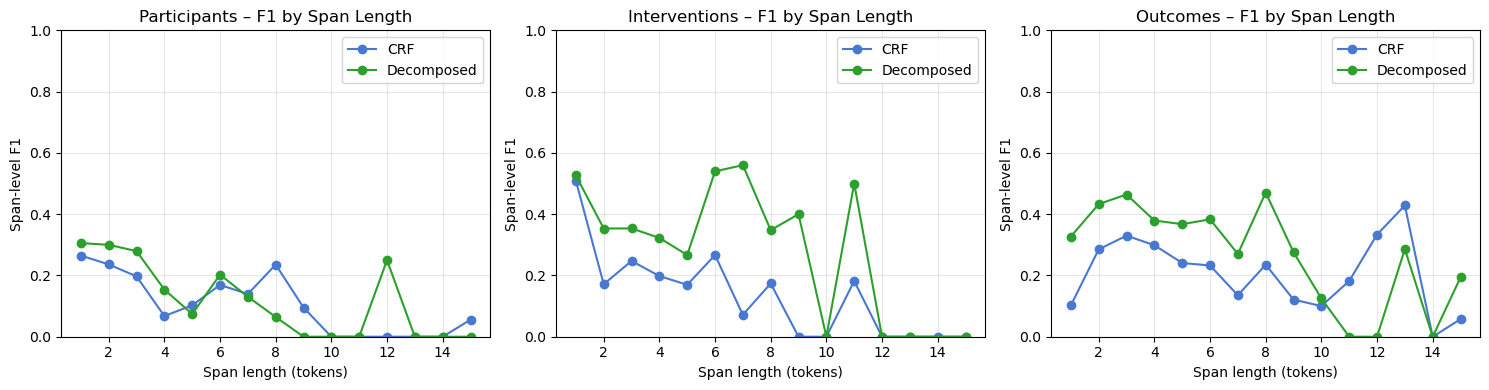

In [25]:
def f1_by_length(gold_seqs, pred_seqs, short, max_len=15):
    """F1 stratified by span length – reveals if longer spans are harder."""
    g_set = set(get_spans(gold_seqs).get(short, []))
    p_set = set(get_spans(pred_seqs).get(short, []))
    buckets = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})
    for span in g_set:
        b = min(span[1] - span[0], max_len)
        if span in p_set: buckets[b]["tp"] += 1
        else:             buckets[b]["fn"] += 1
    for span in p_set:
        b = min(span[1] - span[0], max_len)
        if span not in g_set: buckets[b]["fp"] += 1
    result = {}
    for length, b in sorted(buckets.items()):
        tp, fp, fn = b["tp"], b["fp"], b["fn"]
        p = tp / (tp + fp) if tp + fp > 0 else 0
        r = tp / (tp + fn) if tp + fn > 0 else 0
        result[length] = 2*p*r / (p+r) if p+r > 0 else 0
    return result


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (field, short) in zip(axes, TAG_MAP.items()):
    for apname, preds, col in [("CRF", crf_preds, "#4878CF"),
                                ("Decomposed", decomposed_preds, "#2CA02C")]:
        lf1 = f1_by_length(gold, preds, short)
        xs, ys = zip(*sorted(lf1.items())) if lf1 else ([], [])
        ax.plot(xs, ys, marker="o", label=apname, color=col)
    ax.set_title(f"{field.capitalize()} – F1 by Span Length")
    ax.set_xlabel("Span length (tokens)")
    ax.set_ylabel("Span-level F1")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("f1_by_length.png", bbox_inches="tight", dpi=120)
plt.show()

### 7.2 Coverage vs. Precision by Field

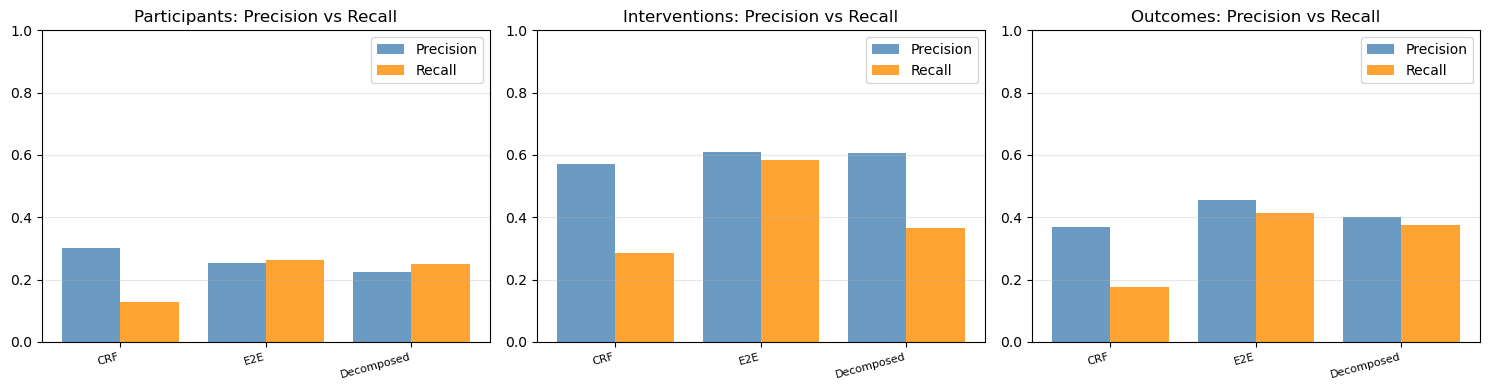

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
approach_list = [("CRF", crf_scores, "#4878CF"),
                 ("E2E", e2e_scores, "#E85D04"),
                 ("Decomposed", decomposed_scores, "#2CA02C")]

for ax, (field, short) in zip(axes, TAG_MAP.items()):
    ap_names = [a for a, _, _ in approach_list]
    precs = [s.get(short, {"precision": 0})["precision"] for _, s, _ in approach_list]
    recs  = [s.get(short, {"recall":    0})["recall"]    for _, s, _ in approach_list]

    xs = np.arange(len(ap_names))
    ax.bar(xs - 0.2, precs, 0.4, label="Precision", color="steelblue",  alpha=0.8)
    ax.bar(xs + 0.2, recs,  0.4, label="Recall",    color="darkorange", alpha=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(ap_names, rotation=15, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"{field.capitalize()}: Precision vs Recall")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("prec_recall_by_field.png", bbox_inches="tight", dpi=120)
plt.show()

---
## 8. Discussion

In [1]:
def print_discussion(all_scores):
    print("\nDiscussion")

    best = max(all_scores, key=lambda k: all_scores[k]["macro"]["f1"])
    print(f"\nBest macro F1: {best}, {all_scores[best]['macro']['f1']:.3f}")

    print("\nMacro average:")
    for name, s in all_scores.items():
        m = s["macro"]
        print(f"  {name}: P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")

    print("\nPer field F1:")
    for short in ["P", "I", "O"]:
        print(f"  {short}:")
        for name, s in all_scores.items():
            print(f"    {name}: {s.get(short, {}).get('f1', 0):.3f}")

    crf_f1 = all_scores["CRF"]["macro"]["f1"]
    e2e_f1 = all_scores["E2E"]["macro"]["f1"]
    dec_f1 = all_scores["Decomposed"]["macro"]["f1"]

## 9. Save outputs

In [28]:
summary.to_csv("results_summary.csv", index=False)
print("saved results_summary.csv")
for fname in ["span_lengths.png", "comparison.png", "f1_by_length.png", "prec_recall_by_field.png"]:
    if os.path.exists(fname):
        print(f"  {fname}")

saved results_summary.csv
  span_lengths.png
  comparison.png
  f1_by_length.png
  prec_recall_by_field.png
